# Qwen3-VL-2B Full Fine-tuning — READ Dataset

Full-parameter fine-tuning of **Qwen3-VL-2B-Instruct** on the READ ICFHR 2016 training set.  
No frozen layers, no LoRA. OCR framed as instruction-following on line-level crops.

| | Choice | Reason |
|---|---|---|
| All parameters | Trainable | ViT adapts to historical Kurrentschrift |
| Optimizer | Adafactor | No per-param moments → ~1 GB vs 16 GB for AdamW → fits 12 GB VRAM |
| Labels | Two-pass processor | Reliable prompt-length counting incl. image tokens |
| Crops | White-padded square | Prevents internal aspect-ratio distortion |
| Prompt | Domain-specific (Ratsprotokolle) | Activates relevant prior knowledge |
| Pixels | min=256·28², max=1280·28² | Balanced resolution for narrow text crops |

## Step 0 — Install

In [ ]:
# Dependencies are pinned in requirements.txt — install once from repo root:
#   pip install -r requirements.txt

## Step 1 — Imports & Paths

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import json
import random
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import evaluate
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor, get_scheduler
from transformers.optimization import Adafactor

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

ROOT     = Path("..")
READ_DIR = ROOT / "data" / "READDataset"
CKPT_DIR = ROOT / "checkpoints" / "best_qwen_ft_read"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 512*28*28 ≈ 401 k pixels → ~512 visual tokens per square-padded crop.
# Full fine-tuning of 2B params needs all remaining VRAM for activations;
# the original 1280*28*28 generated ~1280 tokens and OOM'd.
MIN_PIXELS = 128 * 28 * 28
MAX_PIXELS = 512 * 28 * 28

import transformers
print(f"Device       : {device}")
print(f"transformers : {transformers.__version__}")

Device       : cuda
transformers : 5.13.0.dev0


## Step 2 — Load READ Dataset

In [2]:
PAGE_NS           = "http://schema.primaresearch.org/PAGE/gts/pagecontent/2013-07-15"
KEEP_REGION_TYPES = {"paragraph", "heading"}

SPLITS = {
    "train": {"images": READ_DIR / "Training"    / "Images",
               "xmls":   READ_DIR / "Training"    / "page" / "page"},
    "val":   {"images": READ_DIR / "Validation"  / "Images",
               "xmls":   READ_DIR / "Validation"  / "page" / "page"},
    "test":  {"images": READ_DIR / "Test-ICFHR-2016",
               "xmls":   READ_DIR / "Test-ICFHR-2016" / "page"},
}


def parse_page_xml(xml_path, image_path):
    ns, records = {"p": PAGE_NS}, []
    for region in ET.parse(xml_path).getroot().findall(".//p:TextRegion", ns):
        rtype = region.get("type")
        if rtype is not None and rtype not in KEEP_REGION_TYPES:
            continue
        for line in region.findall(".//p:TextLine", ns):
            u      = line.find(".//p:Unicode", ns)
            coords = line.find("p:Coords", ns)
            if u is None or not (u.text or "").strip() or coords is None:
                continue
            pts  = coords.get("points", "")
            xs   = [int(p.split(",")[0]) for p in pts.split()]
            ys   = [int(p.split(",")[1]) for p in pts.split()]
            bbox = (min(xs), min(ys), max(xs), max(ys))
            if bbox[2] > bbox[0] and bbox[3] > bbox[1]:
                records.append({"image_path": str(image_path),
                                 "bbox": bbox,
                                 "transcription": u.text.strip()})
    return records


def build_df(split):
    paths, records = SPLITS[split], []
    for xml_file in sorted(paths["xmls"].glob("*.xml")):
        img_file = paths["images"] / (xml_file.stem + ".JPG")
        if img_file.exists():
            records.extend(parse_page_xml(xml_file, img_file))
    return pd.DataFrame(records)


df_train = build_df("train")
df_val   = build_df("val")
df_test  = build_df("test")

print(f"Train : {len(df_train):>5} lines")
print(f"Val   : {len(df_val):>5} lines")
print(f"Test  : {len(df_test):>5} lines")

Train :  7140 lines
Val   :   894 lines
Test  :  1138 lines


## Step 3 — Image Preprocessing

Line crops are padded with white to a square before passing to Qwen.  
This prevents Qwen's internal aspect-ratio rescaling from compressing narrow strips.

Original : (1212, 105)  →  Square : (1212, 1212)


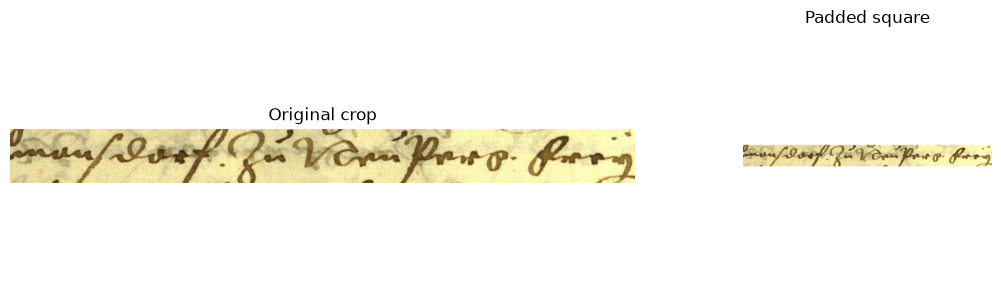

In [3]:
_page_cache: dict = {}

def crop_line(image_path: str, bbox: tuple) -> Image.Image:
    if image_path not in _page_cache:
        _page_cache[image_path] = Image.open(image_path).convert("RGB")
    return _page_cache[image_path].crop(bbox)


def pad_to_square(img: Image.Image, fill: int = 255) -> Image.Image:
    """Pad a PIL image to a square with white background (centered)."""
    w, h  = img.size
    size  = max(w, h)
    canvas = Image.new("RGB", (size, size), (fill, fill, fill))
    canvas.paste(img, ((size - w) // 2, (size - h) // 2))
    return canvas


# Sanity check
row = df_train.iloc[10]
raw  = crop_line(row["image_path"], row["bbox"])
sqr  = pad_to_square(raw)
print(f"Original : {raw.size}  →  Square : {sqr.size}")
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].imshow(raw);  axes[0].set_title("Original crop"); axes[0].axis("off")
axes[1].imshow(sqr);  axes[1].set_title("Padded square"); axes[1].axis("off")
plt.tight_layout(); plt.show()

## Step 4 — Load Model (Selective Freezing)

**Why not train everything?**  
Adafactor calls `p.float()` for each parameter during `.step()`, creating a temporary fp32 copy.  
`lm_head` has 311 M params → **1.16 GB** as fp32 — exactly what OOMs on a 12 GB GPU with everything else loaded.

**What is frozen:**

| Component | Reason |
|---|---|
| `visual.*` except `merger` (ViT encoder) | Quadratic attention over 2048 patches costs 4+ GB during backward recomputation |
| `model.embed_tokens` + `lm_head` | 311 M params each → 1.16 GB fp32 copy in optimizer step; already learned German vocabulary |

**What is trained:** all 28 LLM transformer layers (attention + FFN) + `visual.merger` projection — the parts that learn the historical-cursive → text mapping.

In [4]:
MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=MIN_PIXELS,
    max_pixels=MAX_PIXELS,
)

model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
)

# Freeze via module-level requires_grad_() — more reliable than iterating
# named_parameters(), which deduplicates tied tensors and can silently skip lm_head.

# 1. ViT encoder: backward costs 4+ GB over 2048 patches
model.model.visual.requires_grad_(False)
model.model.visual.merger.requires_grad_(True)  # keep merger trainable

# 2. lm_head: 311M params → 1.16 GiB fp32 copy in Adafactor.step().
#    Called directly on the module so deduplication in named_parameters() cannot skip it.
model.lm_head.requires_grad_(False)

# 3. embed_tokens (usually tied with lm_head, but freeze explicitly to be safe)
model.model.language_model.embed_tokens.requires_grad_(False)

model.gradient_checkpointing_enable()
model.config.use_cache = False
model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total     : {total / 1e6:.1f}M")
print(f"Trainable : {trainable / 1e6:.1f}M  ({trainable / total * 100:.1f}%)")
print(f"Frozen    : {(total - trainable) / 1e6:.1f}M")

print("\nLarge trainable params (> 5M elements) — none should be 311M:")
for name, param in model.named_parameters():
    if param.requires_grad and param.numel() > 5_000_000:
        print(f"  {param.numel()/1e6:6.1f}M  {str(param.shape):30s}  {name}")

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 32.00 MiB. GPU 0 has a total capacity of 11.63 GiB of which 54.00 MiB is free. Process 6404 has 9.87 GiB memory in use. Including non-PyTorch memory, this process has 932.00 MiB memory in use. Of the allocated memory 680.17 MiB is allocated by PyTorch, and 1.83 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Step 5 — Prompt & Training Sample Builder

OCR is framed as instruction-following: the model receives a domain-specific prompt and must output exactly the transcription.  
Loss is computed **only on the response tokens** — the prompt is masked with `-100`.

In [5]:
PROMPT = (
    "You are transcribing a document from the Ratsprotokolle collection — "
    "minutes of council meetings held in Bolzano from 1470 to 1805. "
    "Language: Early Modern German. Script: historical German cursive. "
    "Multiple authors, exact number unknown. "
    "Transcribe the handwritten text in this image exactly as it appears, "
    "preserving all special characters, abbreviations, and diacritics. "
    "Output only the transcription — nothing else."
)


def build_training_sample(pil_image: Image.Image, transcription: str) -> dict:
    img = pad_to_square(pil_image)

    # Pass 1: prompt only → reliable prompt token count (includes image tokens)
    prompt_msgs = [{"role": "user", "content": [
        {"type": "image", "image": img},
        {"type": "text",  "text": PROMPT},
    ]}]
    prompt_text   = processor.apply_chat_template(
        prompt_msgs, tokenize=False, add_generation_prompt=True
    )
    prompt_inputs = processor(text=[prompt_text], images=[img], return_tensors="pt")
    prompt_len    = prompt_inputs.input_ids.shape[1]

    # Pass 2: full conversation (user + assistant response)
    full_msgs = [
        {"role": "user", "content": [
            {"type": "image", "image": img},
            {"type": "text",  "text": PROMPT},
        ]},
        {"role": "assistant", "content": transcription},
    ]
    full_text   = processor.apply_chat_template(full_msgs, tokenize=False, add_generation_prompt=False)
    full_inputs = processor(text=[full_text], images=[img], return_tensors="pt")

    labels = full_inputs.input_ids.clone()
    labels[0, :prompt_len] = -100   # mask everything up to (and incl.) the prompt

    sample = dict(full_inputs)
    sample["labels"] = labels
    return sample


# Sanity check
row    = df_train.iloc[0]
img    = pad_to_square(crop_line(row["image_path"], row["bbox"]))
s      = build_training_sample(img, row["transcription"])
n_resp = (s["labels"][0] != -100).sum().item()
print(f"input_ids shape : {s['input_ids'].shape}")
print(f"Response tokens : {n_resp}  (should be > 0)")
print(f"Transcription   : '{row['transcription']}'")

input_ids shape : torch.Size([1, 468])
Response tokens : 6  (should be > 0)
Transcription   : '1620'


## Step 6 — Training

- `batch_size=1` per step (variable `pixel_values` shape prevents larger batches)
- `gradient_accumulation=8` → effective batch size 8
- **Adafactor** optimizer: no per-param moments → ~1 GB vs 16 GB for AdamW on 2B params
- Early stopping on validation CER (patience = 3)
- Gradient checkpointing saves ~40–50% activation memory at ~20% slower throughput
- `autocast("cuda")` speeds up fp16 forward pass without GradScaler (not needed — no AMP scaling with Adafactor)

In [6]:
EPOCHS        = 10
LR            = 1e-4
GRAD_ACCUM    = 8
PATIENCE      = 3
VAL_SUBSAMPLE = 200

cer_metric = evaluate.load("cer")

# Only pass parameters that require gradients — frozen params have no gradients
# and Adafactor would still create fp32 copies for them during .step() otherwise.
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = Adafactor(
    trainable_params,
    lr=LR,
    scale_parameter=False,
    relative_step=False,
    warmup_init=False,
)

total_steps  = (len(df_train) * EPOCHS) // GRAD_ACCUM
warmup_steps = total_steps // 10
scheduler    = get_scheduler("linear", optimizer,
                              num_warmup_steps=warmup_steps,
                              num_training_steps=total_steps)

print(f"Optimizer steps every {GRAD_ACCUM} samples")
print(f"Total optimizer steps : {total_steps}  |  Warmup : {warmup_steps}")


def val_cer_fast(df_sub, model, processor, device):
    model.eval()
    preds, refs = [], []
    with torch.no_grad():
        for _, row in tqdm(df_sub.iterrows(), total=len(df_sub),
                           desc="  val CER", leave=False):
            img  = pad_to_square(crop_line(row["image_path"], row["bbox"]))
            msgs = [{"role": "user", "content": [
                {"type": "image", "image": img},
                {"type": "text",  "text": PROMPT},
            ]}]
            inputs    = processor.apply_chat_template(
                msgs, tokenize=True, add_generation_prompt=True,
                return_dict=True, return_tensors="pt",
            ).to(device)
            generated = model.generate(**inputs, max_new_tokens=128, do_sample=False)
            trimmed   = [out[len(inp):] for inp, out in zip(inputs.input_ids, generated)]
            pred = processor.batch_decode(trimmed, skip_special_tokens=True,
                                           clean_up_tokenization_spaces=False)[0].strip()
            preds.append(pred)
            refs.append(row["transcription"])
            del inputs, generated
    torch.cuda.empty_cache()
    return cer_metric.compute(predictions=preds, references=refs)


df_val_sub   = df_val.sample(VAL_SUBSAMPLE, random_state=SEED).reset_index(drop=True)
best_cer     = float("inf")
patience_ctr = 0
history      = []

torch.cuda.empty_cache()

for epoch in range(1, EPOCHS + 1):

    model.train()
    total_loss = 0.0
    optimizer.zero_grad()

    df_shuffled = df_train.sample(frac=1, random_state=SEED + epoch).reset_index(drop=True)

    for step, (_, row) in enumerate(
        tqdm(df_shuffled.iterrows(), total=len(df_shuffled),
             desc=f"Epoch {epoch:02d}/{EPOCHS} [train]", leave=False)
    ):
        img    = pad_to_square(crop_line(row["image_path"], row["bbox"]))
        sample = build_training_sample(img, row["transcription"])
        inputs = {k: v.to(device) for k, v in sample.items()}

        with torch.amp.autocast("cuda"):
            outputs = model(**inputs)

        loss = outputs.loss / GRAD_ACCUM
        loss.backward()
        total_loss += outputs.loss.item()

        del inputs, outputs, sample, loss
        torch.cuda.empty_cache()

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
            optimizer.step()
            optimizer.zero_grad()
            scheduler.step()

    avg_loss = total_loss / len(df_train)
    val_cer  = val_cer_fast(df_val_sub, model, processor, device)

    history.append({"epoch": epoch, "train_loss": avg_loss, "val_cer": val_cer})
    print(f"Epoch {epoch:02d} | Loss: {avg_loss:.4f} | Val CER (n={VAL_SUBSAMPLE}): {val_cer:.4f}", end="")

    if val_cer < best_cer:
        best_cer     = val_cer
        patience_ctr = 0
        model.save_pretrained(CKPT_DIR)
        processor.save_pretrained(CKPT_DIR)
        print("  ✓ best saved")
    else:
        patience_ctr += 1
        print(f"  ✗ no improvement ({patience_ctr}/{PATIENCE})")
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping — best Val CER: {best_cer:.4f}")
            break

Optimizer steps every 8 samples
Total optimizer steps : 8925  |  Warmup : 892


Epoch 01/10 [train]:   0%|          | 0/7140 [00:00<?, ?it/s]

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


  val CER:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 01 | Loss: 2.0054 | Val CER (n=200): 0.8211

...

Epoch 10/10 [train]:   0%|          | 0/7140 [00:00<?, ?it/s]

  val CER:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 10 | Loss: 0.0005 | Val CER (n=200): 0.1693

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ best saved


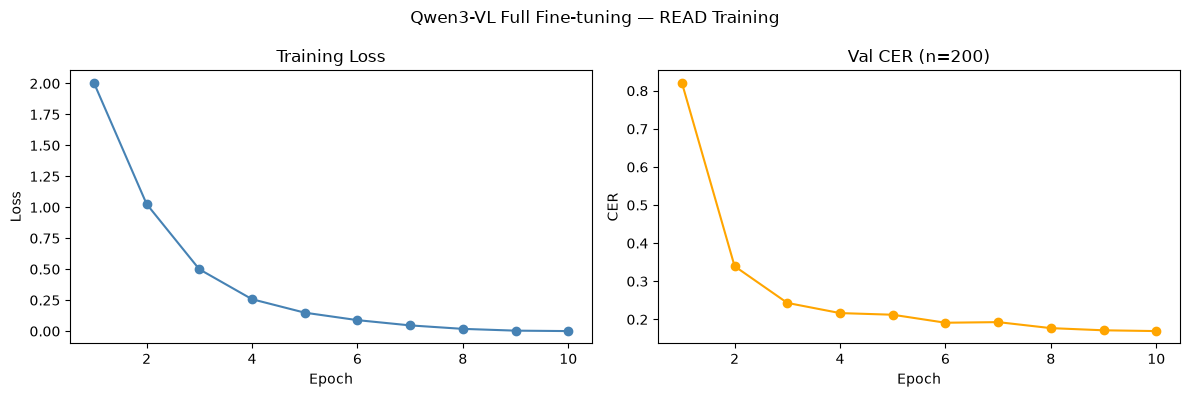

Best Val CER: 0.1693 (Epoch 10)


In [7]:
history_df = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_df["epoch"], history_df["train_loss"], marker="o", color="steelblue")
ax1.set_title("Training Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")

ax2.plot(history_df["epoch"], history_df["val_cer"], marker="o", color="orange")
ax2.set_title(f"Val CER (n={VAL_SUBSAMPLE})"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("CER")

plt.suptitle("Qwen3-VL Full Fine-tuning — READ Training", fontsize=12)
plt.tight_layout()
plt.savefig(CKPT_DIR / "training_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best Val CER: {history_df['val_cer'].min():.4f} (Epoch {history_df['val_cer'].idxmin() + 1})")

## Step 7 — Evaluation on Test Set

Self-contained — can be run after a kernel restart without retraining.

In [8]:
# ── Reload best checkpoint ────────────────────────────────────────────────────
eval_processor = AutoProcessor.from_pretrained(
    CKPT_DIR, min_pixels=MIN_PIXELS, max_pixels=MAX_PIXELS
)

eval_model = Qwen3VLForConditionalGeneration.from_pretrained(
    CKPT_DIR, torch_dtype=torch.float16
).to(device)
eval_model.eval()

print(f"Loaded fine-tuned checkpoint from {CKPT_DIR}")

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 24.00 MiB. GPU 0 has a total capacity of 11.63 GiB of which 33.69 MiB is free. Including non-PyTorch memory, this process has 10.79 GiB memory in use. Of the allocated memory 10.36 GiB is allocated by PyTorch, and 118.72 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [9]:
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

all_preds, all_refs = [], []

with torch.no_grad():
    for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc="Evaluating"):
        img  = pad_to_square(crop_line(row["image_path"], row["bbox"]))
        msgs = [{"role": "user", "content": [
            {"type": "image", "image": img},
            {"type": "text",  "text": PROMPT},
        ]}]
        inputs    = eval_processor.apply_chat_template(
            msgs, tokenize=True, add_generation_prompt=True,
            return_dict=True, return_tensors="pt"
        ).to(device)
        generated = eval_model.generate(**inputs, max_new_tokens=128, do_sample=False)
        trimmed   = [out[len(inp):] for inp, out in zip(inputs.input_ids, generated)]
        pred = eval_processor.batch_decode(
            trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )[0].strip()
        all_preds.append(pred)
        all_refs.append(row["transcription"])

ft_cer = cer_metric.compute(predictions=all_preds, references=all_refs)
ft_wer = wer_metric.compute(predictions=all_preds, references=all_refs)

print(f"\nQwen3-VL-2B Full Fine-tuning")
print(f"  CER : {ft_cer:.4f}  ({ft_cer * 100:.2f}%)")
print(f"  WER : {ft_wer:.4f}  ({ft_wer * 100:.2f}%)")

Evaluating:   0%|          | 0/1138 [00:00<?, ?it/s]

NameError: name 'eval_model' is not defined

## Step 8 — Comparison Table

In [10]:
# Load zero-shot Qwen predictions if available
zeroshot_preds_path = ROOT / "checkpoints" / "qwen3vl_read_predictions.json"
zeroshot_cer, zeroshot_wer = None, None
if zeroshot_preds_path.exists():
    with open(zeroshot_preds_path, encoding="utf-8") as f:
        zeroshot_preds = json.load(f)
    if len(zeroshot_preds) == len(all_refs):
        zeroshot_cer = round(cer_metric.compute(predictions=zeroshot_preds, references=all_refs) * 100, 2)
        zeroshot_wer = round(wer_metric.compute(predictions=zeroshot_preds, references=all_refs) * 100, 2)

rows = [
    {"Modell": "TrOCR Elastic Aug",              "Typ": "Fine-tuned",   "CER (%)": 7.02,  "WER (%)": 28.69},
    {"Modell": "Qwen3-VL-2B Full Fine-tuning",   "Typ": "Fine-tuned",   "CER (%)": round(ft_cer * 100, 2), "WER (%)": round(ft_wer * 100, 2)},
]
if zeroshot_cer is not None:
    rows.insert(0, {"Modell": "Qwen3-VL-2B zero-shot", "Typ": "Zero-shot", "CER (%)": zeroshot_cer, "WER (%)": zeroshot_wer})

df_results = pd.DataFrame(rows).set_index("Modell")

print("=" * 60)
print("READ Test Set (ICFHR 2016) — CER / WER")
print("=" * 60)
display(df_results.sort_values("CER (%)"))

NameError: name 'ft_cer' is not defined

In [11]:
colors = ["#aec7e8", "#1f77b4", "#ff7f0e"][:len(df_results)]
labels = df_results.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ["CER (%)", "WER (%)"]):
    vals = df_results.loc[labels, metric].values
    bars = ax.bar(labels, vals, color=colors, edgecolor="white", width=0.5)
    ax.set_title(f"READ Test Set — {metric}", fontsize=12)
    ax.set_ylabel(metric)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
    ax.set_ylim(0, max(vals) * 1.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Qwen3-VL Full Fine-tuning vs TrOCR — READ ICFHR 2016 Test Set", fontsize=12)
plt.tight_layout()
plt.savefig(CKPT_DIR / "comparison.png", dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'df_results' is not defined

## Step 9 — Qualitative Examples & Worst Predictions

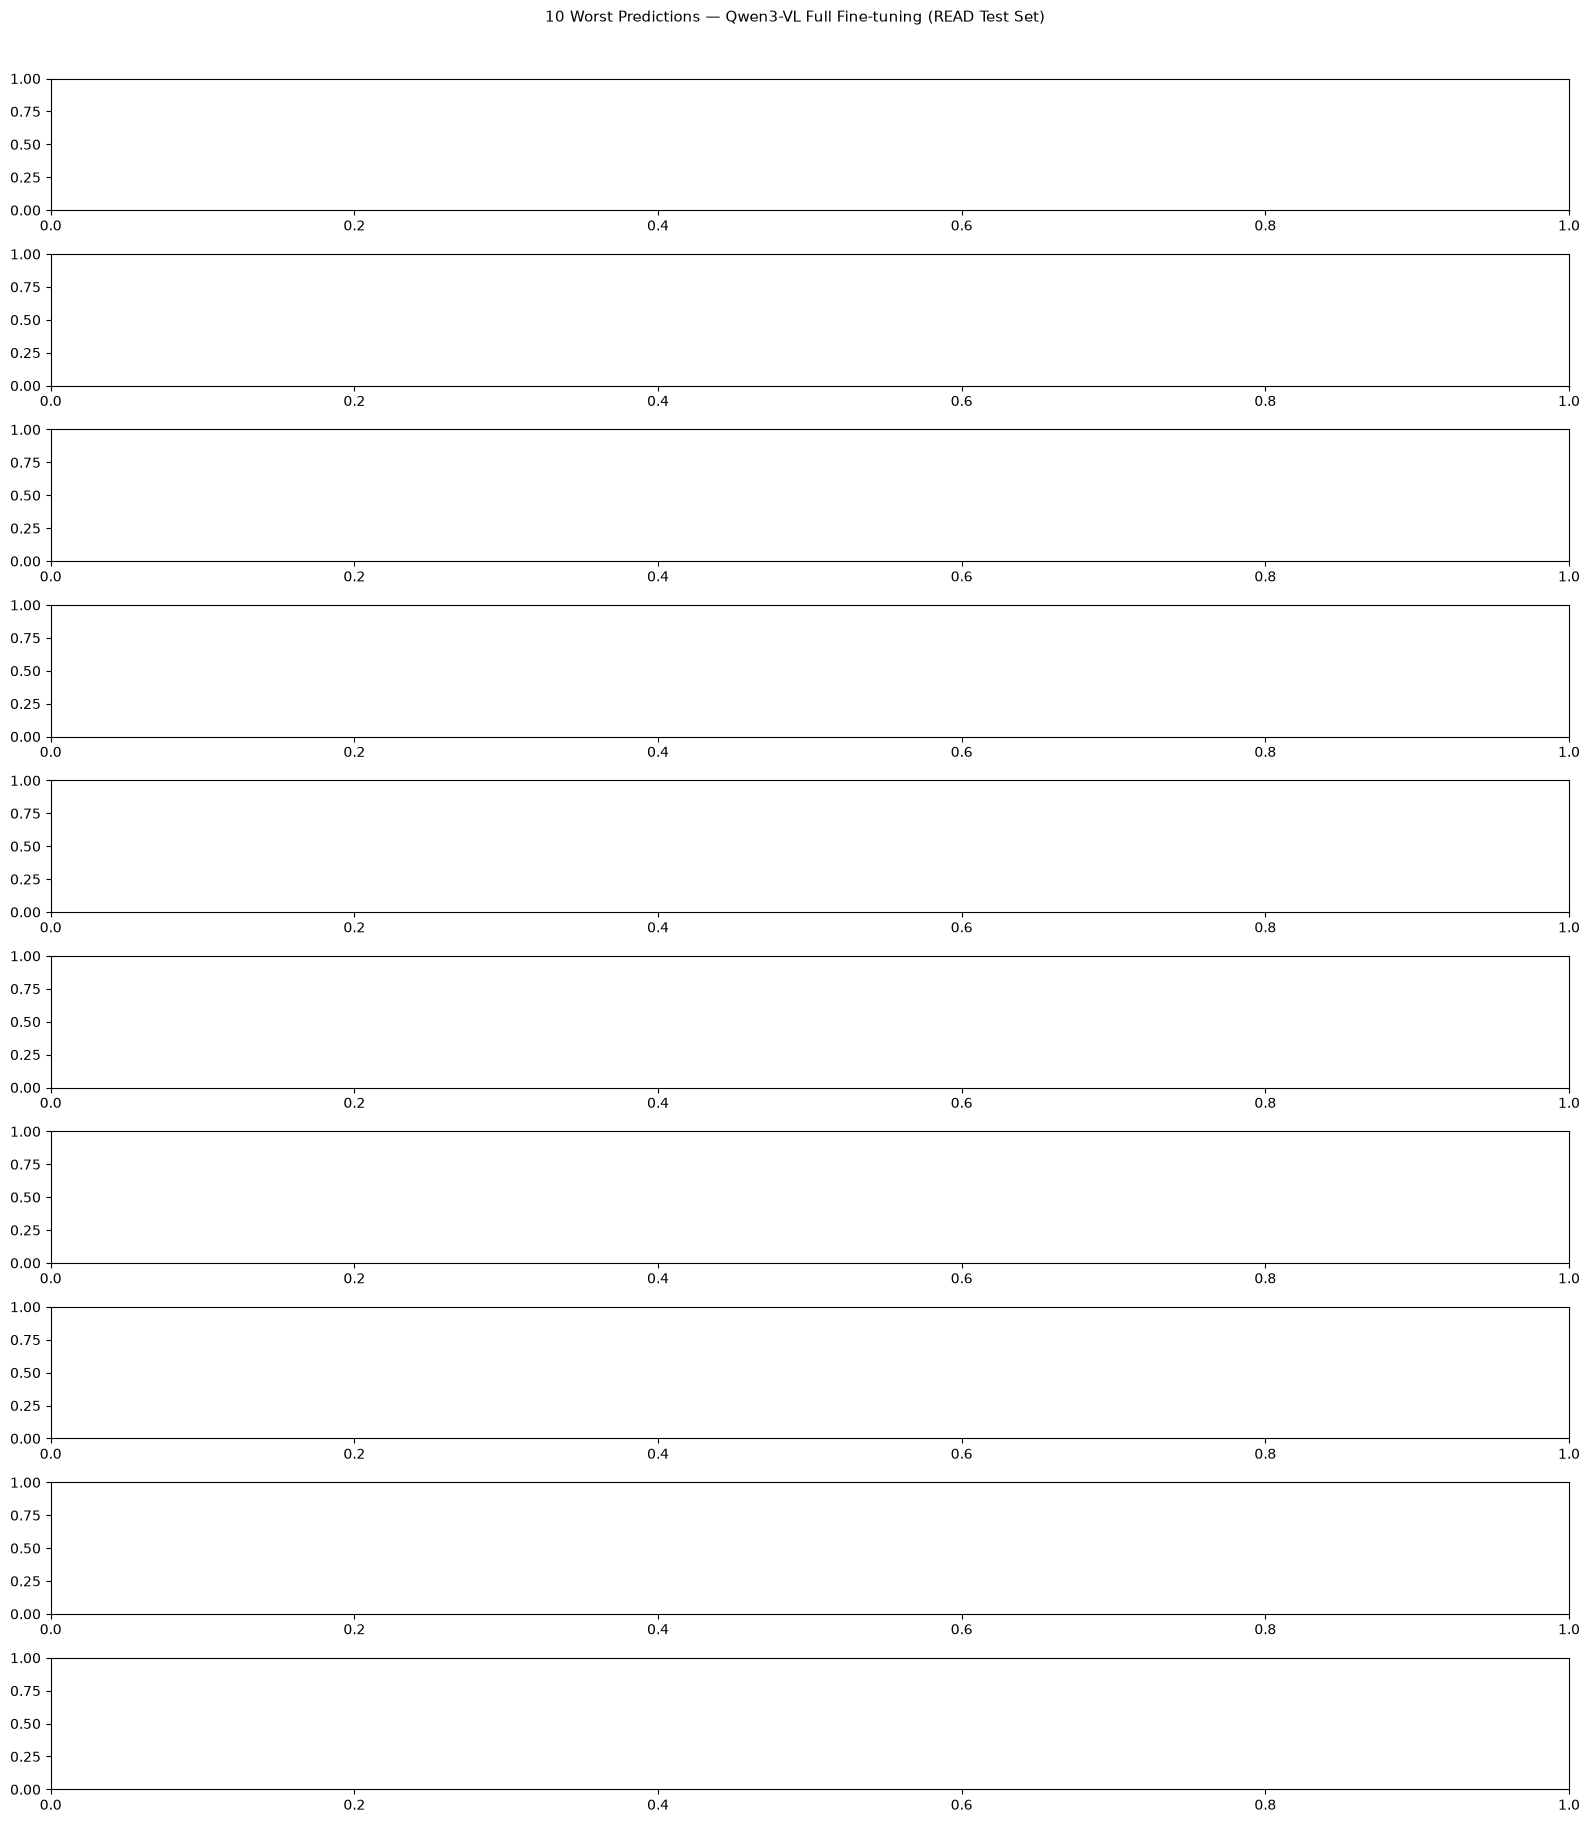

In [12]:
from jiwer import cer as line_cer

errors = sorted(
    [(line_cer(ref, pred), idx, ref, pred)
     for idx, (pred, ref) in enumerate(zip(all_preds, all_refs)) if ref.strip()],
    reverse=True,
)
worst = errors[:10]

fig, axes = plt.subplots(10, 1, figsize=(16, 18))
for ax, (c, idx, ref, pred) in zip(axes, worst):
    row  = df_test.iloc[idx]
    img  = pad_to_square(crop_line(row["image_path"], row["bbox"]))
    ax.imshow(img)
    ax.set_title(
        f"CER {c:.2f}  |  GT        : {ref}\n"
        f"            |  Qwen FT   : {pred}",
        fontsize=8, loc="left", pad=3, family="monospace",
    )
    ax.axis("off")

plt.suptitle("10 Worst Predictions — Qwen3-VL Full Fine-tuning (READ Test Set)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(CKPT_DIR / "worst_predictions.png", dpi=150, bbox_inches="tight")
plt.show()